# SHAP

## teoria w pigułce i praktyka (drzewa i modele liniowe), interpretacja wykresów.

# Cel zajęć

Po zajęciach student:

* rozumie ideę SHAP (Shapley values)
* potrafi używać SHAP dla różnych modeli
* rozumie różnicę między SHAP a LIME
* potrafi interpretować wykresy SHAP

# 1. Dlaczego SHAP?

Problem LIME:

* losowość
* niestabilność
* brak jednoznaczności

SHAP próbuje to naprawić.

# 2. Idea SHAP

SHAP opiera się na koncepcji z teorii gier:

> **wartości Shapleya**

Wyobraź sobie, że:

* model = gra
* cechy = gracze
* wynik = predykcja

SHAP odpowiada:

> „ile każda cecha wnosi do wyniku?”

## Kluczowa własność

$
prediction = baseline + suma\ wkładów\ cech
$

`SHAP` (SHapley Additive exPlanations) to metoda wyjaśniania modeli uczenia maszynowego oparta na teorii gier, która przypisuje każdej cesze wkład w predykcję modelu w sposób spójny i matematycznie uzasadniony. Działa poprzez obliczanie tzw. wartości Shapleya, które określają, ile dana cecha wnosi do wyniku modelu względem wartości bazowej (średniej predykcji), biorąc pod uwagę wszystkie możliwe kombinacje cech. W praktyce oznacza to, że każda predykcja jest rozkładana na sumę wkładów poszczególnych cech, co pozwala jednocześnie uzyskać wyjaśnienia lokalne (dla pojedynczej obserwacji) i globalne (dla całego modelu). SHAP jest metodą post-hoc i model-agnostic (choć ma zoptymalizowane wersje dla drzew i modeli liniowych), a jego główną zaletą jest stabilność i jednoznaczność interpretacji w porównaniu do metod takich jak LIME.


# 3. Najważniejsza różnica vs LIME

| LIME                 | SHAP                  |
| -------------------- | --------------------- |
| losowy               | deterministyczny      |
| lokalne przybliżenie | dokładna dekompozycja |
| może być niestabilny | stabilny              |

# 4. Instalacja

In [130]:
!pip install shap

# 5. Warsztat – model drzewiasty

## Import

In [131]:
import shap

In [132]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

## Dane

In [133]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

## Model

In [134]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

## Explainer (dla drzew)

In [135]:
explainer = shap.TreeExplainer(model)

## SHAP values

SHAP values obliczone za pomocą `shap_values = explainer.shap_values(X_test)` to wartości przypisujące każdej cesze jej wkład w predykcję modelu dla każdej obserwacji w zbiorze `X_test`. Dla każdej próbki i każdej cechy wartość SHAP określa, o ile dana cecha zwiększa lub zmniejsza wynik modelu względem wartości bazowej (średniej predykcji modelu). Suma wszystkich wartości SHAP dla danej obserwacji, powiększona o wartość bazową (`expected_value`), daje dokładnie predykcję modelu dla tej próbki. W przypadku klasyfikacji wynik często jest zwracany osobno dla każdej klasy (np. `shap_values[1, :, :]` dla klasy pozytywnej), a znak i wartość liczby wskazują kierunek i siłę wpływu danej cechy na decyzję modelu.

In [136]:
shap_values = explainer.shap_values(X_test,y_test)
shap_values

array([[[ 2.95924520e-02, -2.95924520e-02],
        [ 1.27547712e-02, -1.27547712e-02],
        [ 3.46052391e-02, -3.46052391e-02],
        ...,
        [ 6.71687515e-02, -6.71687515e-02],
        [-5.14717265e-04,  5.14717265e-04],
        [-8.61652708e-04,  8.61652708e-04]],

       [[-1.34362600e-02,  1.34362600e-02],
        [-3.02021882e-03,  3.02021882e-03],
        [-1.84146658e-02,  1.84146658e-02],
        ...,
        [-3.30387786e-02,  3.30387786e-02],
        [-5.70046546e-03,  5.70046546e-03],
        [-1.84187500e-03,  1.84187500e-03]],

       [[-5.16993712e-03,  5.16993712e-03],
        [ 1.89194629e-02, -1.89194629e-02],
        [-1.18606380e-02,  1.18606380e-02],
        ...,
        [ 9.11954803e-02, -9.11954803e-02],
        [ 1.44904563e-02, -1.44904563e-02],
        [ 2.02564892e-02, -2.02564892e-02]],

       ...,

       [[ 3.09702395e-02, -3.09702395e-02],
        [-4.55897981e-03,  4.55897981e-03],
        [ 3.97223426e-02, -3.97223426e-02],
        ...,
     

# 6. Interpretacja pojedynczej obserwacji

Poniższy fragment kodu tworzy **lokalne wyjaśnienie SHAP dla jednej konkretnej obserwacji** i wizualizuje je jako wykres typu *waterfall* (czyli „krok po kroku, jak cechy budują predykcję”).

Najpierw wybierasz jedną próbkę:

```python
i = 0
```

oznacza to: „analizujemy pierwszą obserwację ze zbioru testowego”

Następnie tworzysz obiekt wyjaśnienia:

```python
shap.Explanation(
    values=shap_values[1][i],
    base_values=explainer.expected_value[1],
    data=X_test.iloc[i]
)
```

### Co tu jest czym?

* `values=shap_values[1][i]`
  wkłady SHAP dla każdej cechy dla tej jednej obserwacji
  (dla klasy 1, czyli np. „benign”)

* `base_values=explainer.expected_value[1]`
  wartość bazowa = średnia predykcja modelu
  (punkt startowy wykresu)

* `data=X_test.iloc[i]`
  rzeczywiste wartości cech tej obserwacji
  (żeby opisać wykres)

Na końcu:

```python
shap.plots.waterfall(...)
```

rysuje wykres, który pokazuje:

1. start od **base value** (średnia predykcja)
2. każda cecha:

   * przesuwa wynik w prawo (zwiększa predykcję) 🔴
   * lub w lewo (zmniejsza predykcję) 🔵
3. suma wszystkich przesunięć = **końcowa predykcja modelu**

In [137]:
i = 15
sample = X_test.iloc[i]

In [138]:
shap_values.shape

(114, 30, 2)

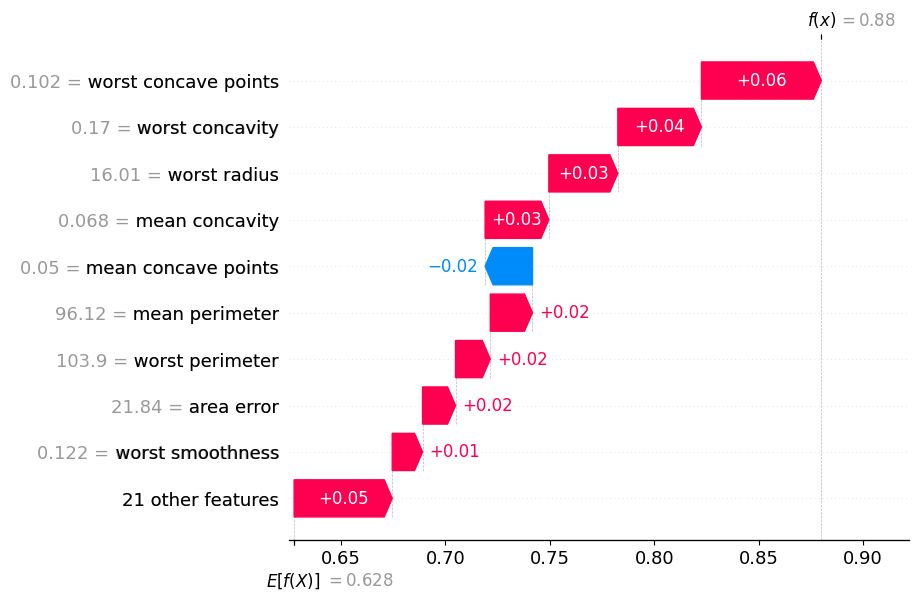

In [139]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[i, :, 1],
        base_values=explainer.expected_value[1],
        data=sample
    )
)

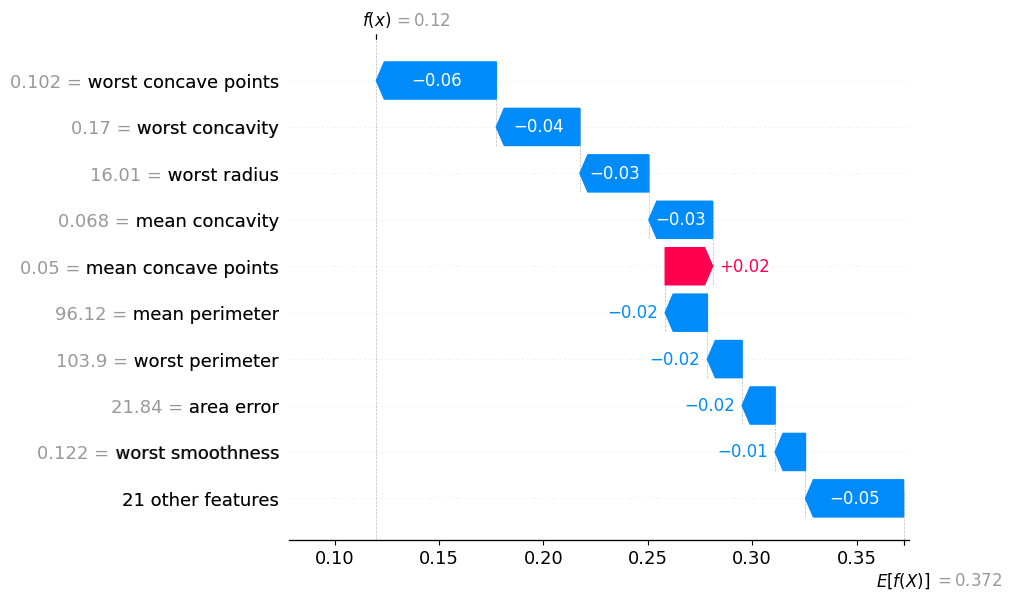

In [140]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[i, :, 0],
        base_values=explainer.expected_value[0],
        data=sample
    )
)

## Interpretacja

Ten wykres odpowiada na pytanie:

> Jak model doszedł do tej konkretnej decyzji?

* **base value** → średnia predykcja modelu
* każda cecha → przesuwa wynik w górę/dół
* suma → końcowa predykcja

Możesz to czytać tak:

> Zaczynamy od średniej predykcji modelu, a potem każda cecha mówi: dodaj tyle / odejmij tyle — aż dojdziemy do końcowego wyniku.

> Waterfall SHAP pokazuje dokładnie, jak każda cecha przesuwa predykcję od średniej do końcowej decyzji.

In [144]:
model.predict(pd.DataFrame(sample).T)[0]

1

# 7. Globalna interpretacja

##  Summary plot

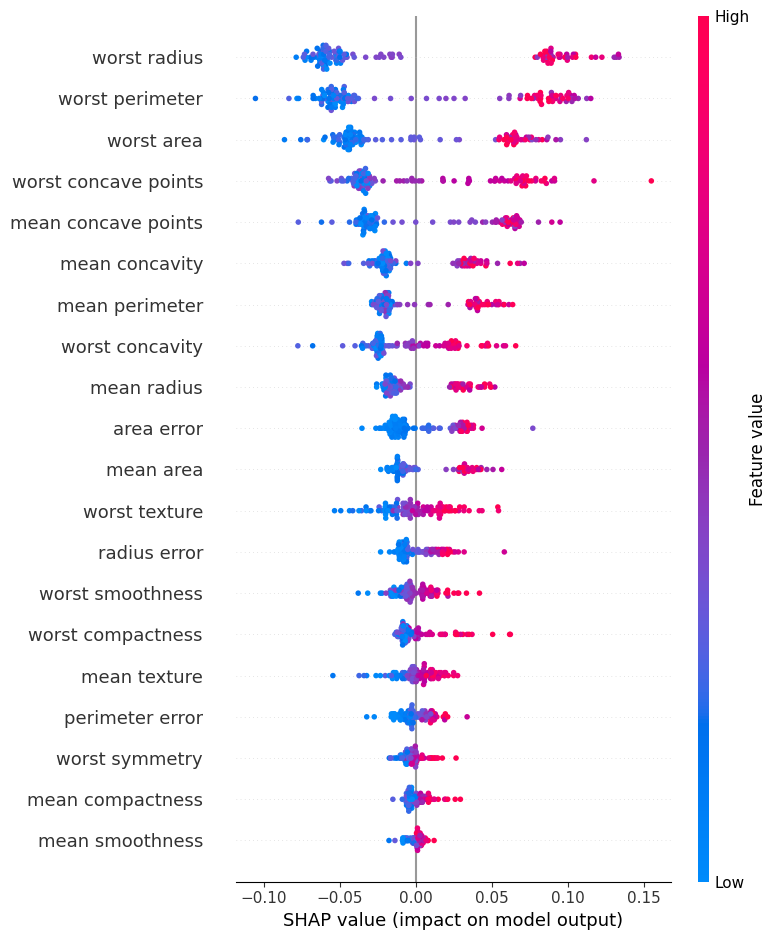

In [145]:
shap.summary_plot(shap_values[:, :, 0], X_test)

## Jak czytać

* oś X → wpływ na model
* kolor → wartość cechy
* rozrzut → zmienność wpływu

## Interpretacja

* cechy na górze → najważniejsze
* czerwone po prawej → wysokie wartości zwiększają predykcję
* niebieskie po lewej → zmniejszają

# 8. Feature importance (SHAP)

Czyli średnia wartość |SHAP|.

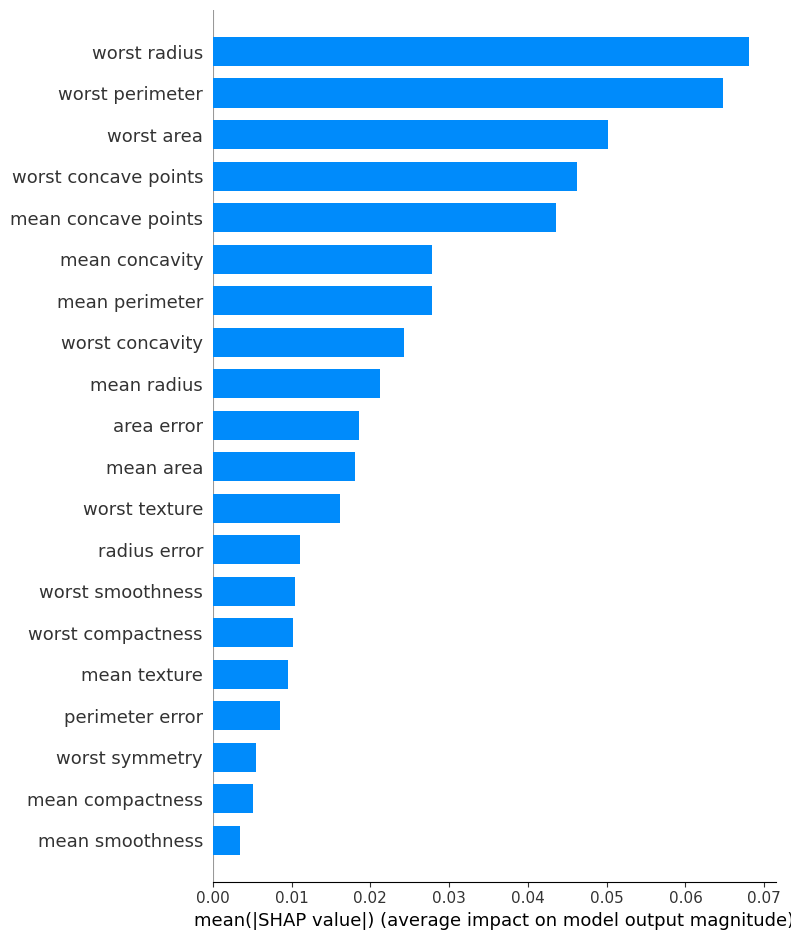

In [146]:
shap.summary_plot(shap_values[:, :, 0], X_test, plot_type="bar")

# 9. SHAP vs PDP

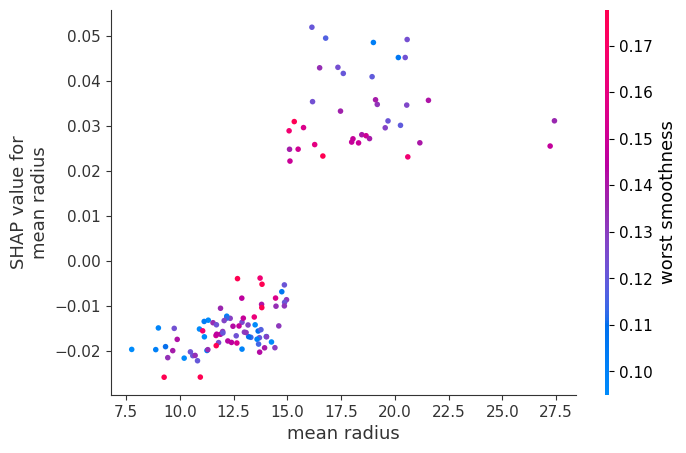

In [147]:
shap.dependence_plot("mean radius", shap_values[:, :, 0], X_test)

##  Interpretacja

* X → wartość cechy
* Y → wpływ na predykcję
* kolor → inna cecha (interakcje!)

# 10. Modele liniowe (Logistic Regression)

## Skalowanie danych

In [160]:
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=data.feature_names)

In [161]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

## Model

In [162]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=500)

In [163]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=500)


## Explainer

In [172]:
explainer = shap.LinearExplainer(model, X_train)
shap_values = explainer.shap_values(X_test)

i = 15
sample = X_test.iloc[i]
sample

mean radius                0.210940
mean texture               0.214172
mean perimeter             0.170979
mean area                  0.073978
mean smoothness           -0.034891
mean compactness          -0.395915
mean concavity            -0.258122
mean concave points        0.015240
mean symmetry             -1.185164
mean fractal dimension    -0.753827
radius error              -0.623932
texture error              0.760476
perimeter error           -0.628718
area error                -0.406967
smoothness error          -0.542015
compactness error         -0.657716
concavity error           -0.343630
concave points error       0.005493
symmetry error            -0.115303
fractal dimension error   -0.750036
worst radius              -0.053674
worst texture              0.456415
worst perimeter           -0.100117
worst area                -0.170488
worst smoothness          -0.472051
worst compactness         -0.734519
worst concavity           -0.490252
worst concave points      -0

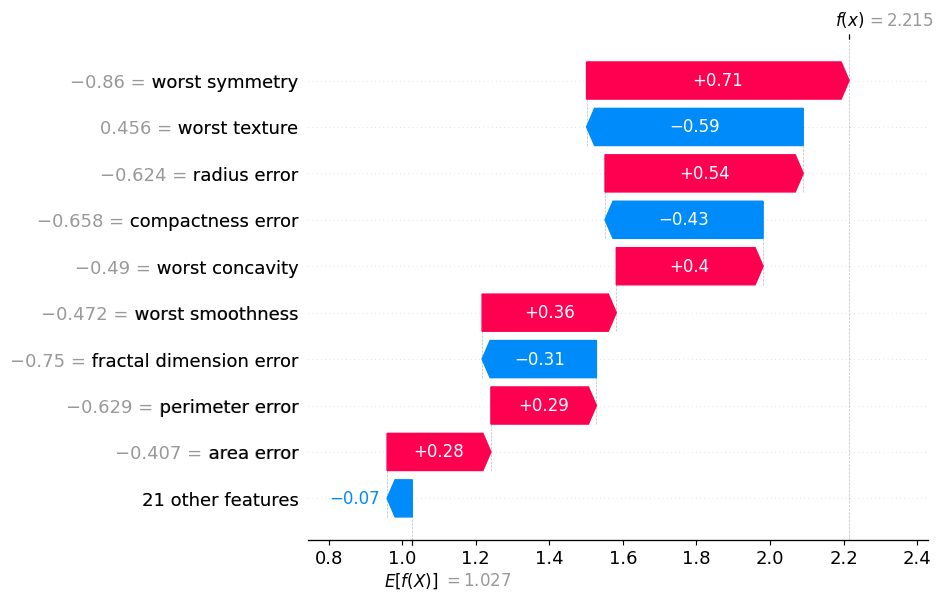

In [173]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value,
        data=sample
    )
)

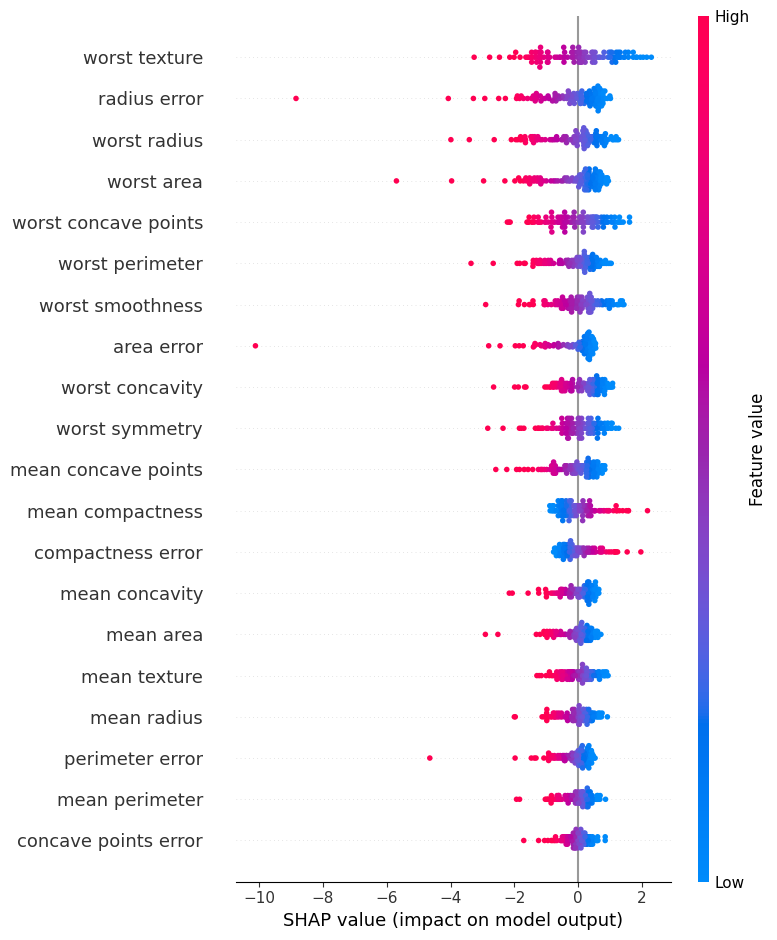

In [174]:
shap.summary_plot(shap_values, X_test)

In [175]:
model.predict(pd.DataFrame(sample).T)[0]

1

Dla modeli liniowych:

- SHAP ≈ coef * feature

- czyli to, co robiliśmy wcześniej ręcznie

# 11. Najważniejsze wykresy SHAP

### Waterfall (lokalne)

→ dlaczego ta decyzja

### Summary (globalne)

→ co ważne ogólnie

### Dependence

→ jak cecha wpływa

# 12. Największe zalety SHAP

- spójność matematyczna
- brak losowości
- lokalne + globalne
- działa dla różnych modeli

## Ograniczenia SHAP

* wolniejszy dla dużych modeli
* trudniejszy matematycznie
* baseline może być mylący

# 13. Porównanie metod

| metoda      | typ            |
| ----------- | -------------- |
| permutation | global         |
| PDP         | global         |
| LIME        | lokal          |
| SHAP        | lokal + global |



> „SHAP rozkłada predykcję modelu na wkład każdej cechy w sposób spójny i stabilny.”

# Zadanie dla studentów

1. Zrób SHAP dla RandomForest dla innego zbioru danych
2. Zrób SHAP dla Logistic Regression dla innego zbioru danych
3. Porównaj wyniki
4. Sprawdź zgodność z PDP i LIME
